# 01 — Exploratory Data Analysis
**DataStorm v7.0 | SkyNet Team**

Goal: Understand distributions, outliers, and patterns in the gold-layer data before modelling.

In [19]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

SILVER_DIR = ROOT / 'data' / 'silver'
GOLD_DIR   = ROOT / 'data' / 'gold'

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Paths OK:', GOLD_DIR.exists())

Paths OK: True


## 1. Load Datasets

In [20]:
tx      = pd.read_csv(SILVER_DIR / 'transactions_clean.csv', low_memory=False)
master  = pd.read_csv(SILVER_DIR / 'outlet_master_clean.csv', low_memory=False)
coords  = pd.read_csv(SILVER_DIR / 'coordinates_clean.csv', low_memory=False)
season  = pd.read_csv(SILVER_DIR / 'seasonality_clean.csv', low_memory=False)
holiday = pd.read_csv(SILVER_DIR / 'holidays_clean.csv', low_memory=False, parse_dates=['Date'])
gold    = pd.read_csv(GOLD_DIR   / 'outlet_features.csv', low_memory=False)

for col in ['Year', 'Month', 'Volume_Liters', 'Total_Bill_Value']:
    if col in tx.columns:
        tx[col] = pd.to_numeric(tx[col], errors='coerce')

print('Transactions:', tx.shape)
print('Outlet Master:', master.shape)
print('Coordinates:', coords.shape)
print('Seasonality:', season.shape)
print('Gold:', gold.shape)

Transactions: (1262697, 7)
Outlet Master: (10492, 4)
Coordinates: (10352, 3)
Seasonality: (360, 4)
Gold: (10492, 50)


## 2. Transactions — Volume Distribution

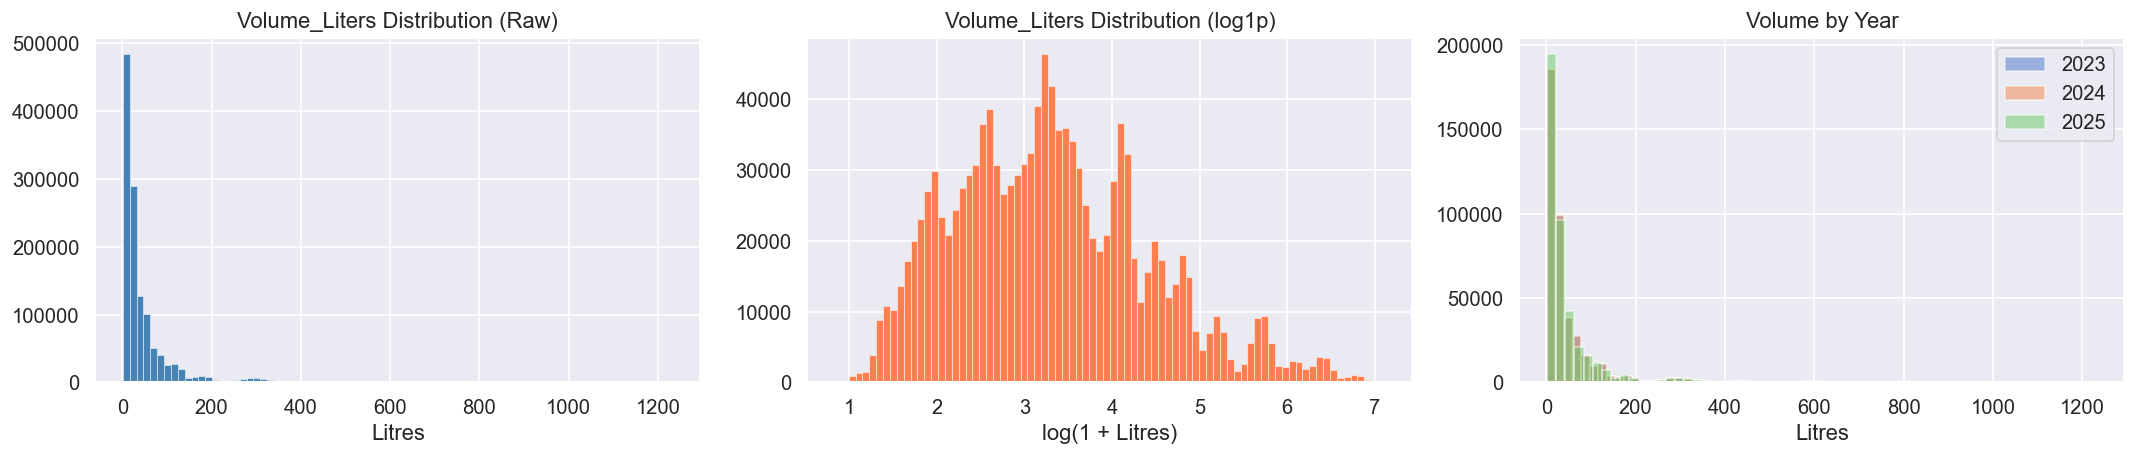

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Raw distribution
axes[0].hist(tx['Volume_Liters'].dropna(), bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Volume_Liters Distribution (Raw)')
axes[0].set_xlabel('Litres')

# Log-transformed
log_vol = np.log1p(tx['Volume_Liters'].dropna())
axes[1].hist(log_vol, bins=80, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title('Volume_Liters Distribution (log1p)')
axes[1].set_xlabel('log(1 + Litres)')

# By Year
for yr, grp in tx.groupby('Year'):
    axes[2].hist(grp['Volume_Liters'].dropna(), bins=60, alpha=0.5, label=str(yr))
axes[2].set_title('Volume by Year')
axes[2].set_xlabel('Litres')
axes[2].legend()

plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_volume_dist.png', bbox_inches='tight')
plt.show()

## 3. Monthly Volume Trend (2023–2025)

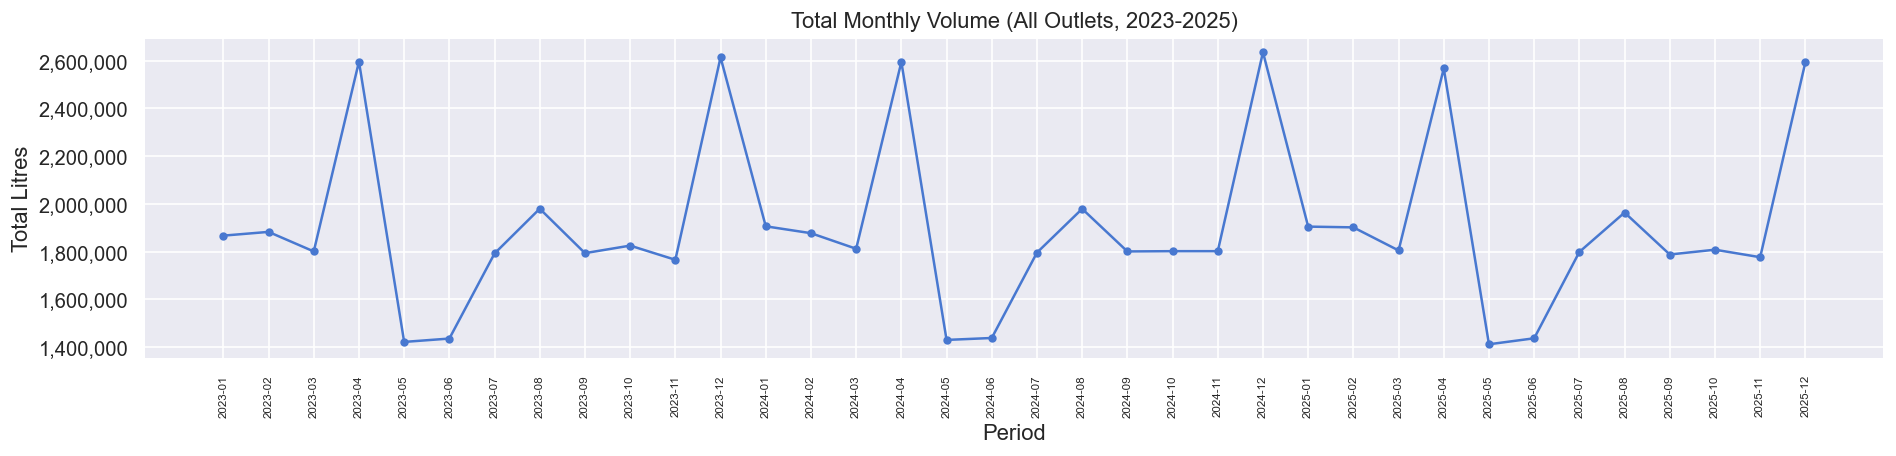

In [22]:
tx['period'] = tx['Year'].astype(str) + '-' + tx['Month'].astype(str).str.zfill(2)
monthly_total = tx.groupby('period')['Volume_Liters'].sum().reset_index().sort_values('period')

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(monthly_total['period'], monthly_total['Volume_Liters'], marker='o', markersize=4, linewidth=1.5)
ax.set_title('Total Monthly Volume (All Outlets, 2023-2025)')
ax.set_xlabel('Period')
ax.set_ylabel('Total Litres')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_monthly_trend.png', bbox_inches='tight')
plt.show()

## 4. Outlet Type & Size Analysis

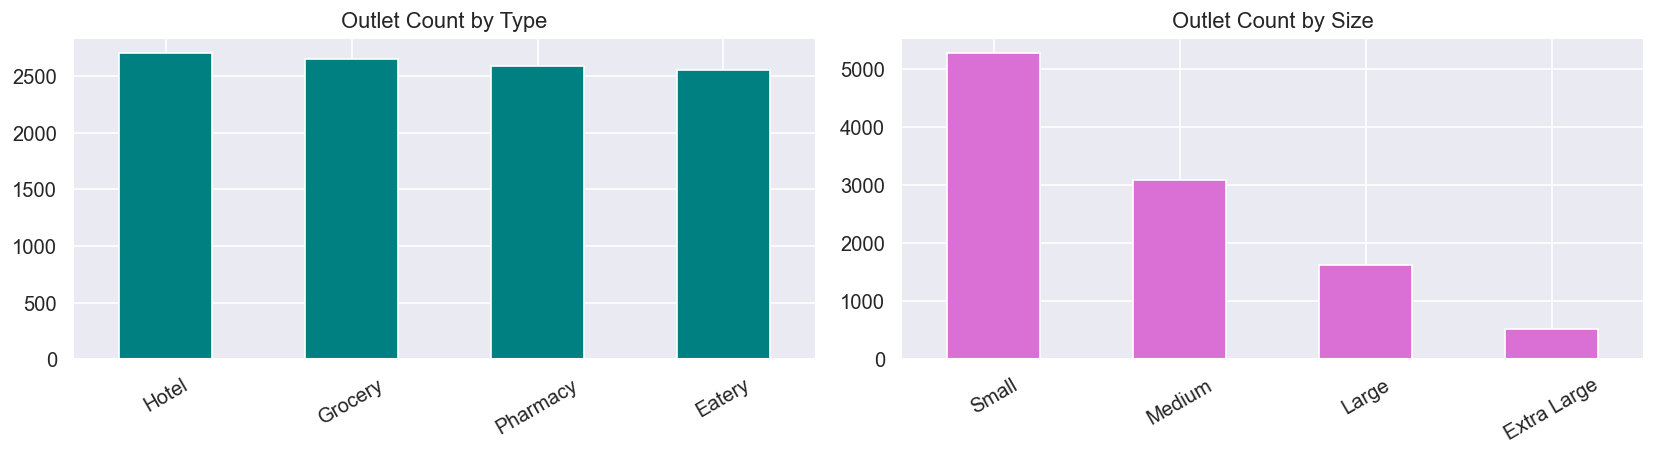

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

master['Outlet_Type'].value_counts().plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Outlet Count by Type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

size_order = ['Small', 'Medium', 'Large', 'Extra Large']
master['Outlet_Size'].value_counts().reindex(size_order).dropna().plot(
    kind='bar', ax=axes[1], color='orchid', edgecolor='white')
axes[1].set_title('Outlet Count by Size')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_outlet_breakdown.png', bbox_inches='tight')
plt.show()

## 5. Volume vs. Outlet Type (Boxplot)

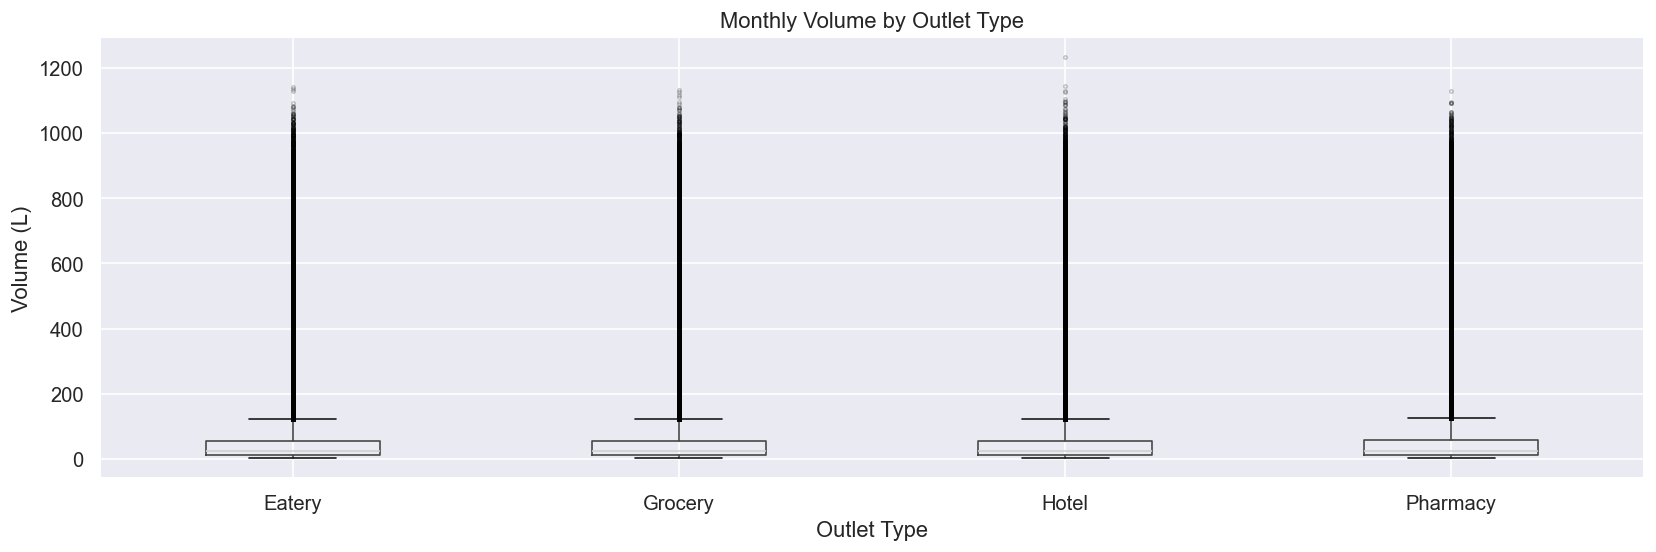

In [24]:
tx_master = tx.merge(master[['Outlet_ID', 'Outlet_Type', 'Outlet_Size']], on='Outlet_ID', how='left')

fig, ax = plt.subplots(figsize=(14, 5))
tx_master.boxplot(column='Volume_Liters', by='Outlet_Type', ax=ax,
                  flierprops=dict(marker='o', alpha=0.2, markersize=2))
ax.set_title('Monthly Volume by Outlet Type')
ax.set_xlabel('Outlet Type')
ax.set_ylabel('Volume (L)')
plt.suptitle('')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_volume_by_type.png', bbox_inches='tight')
plt.show()

## 6. Seasonality Index Distribution

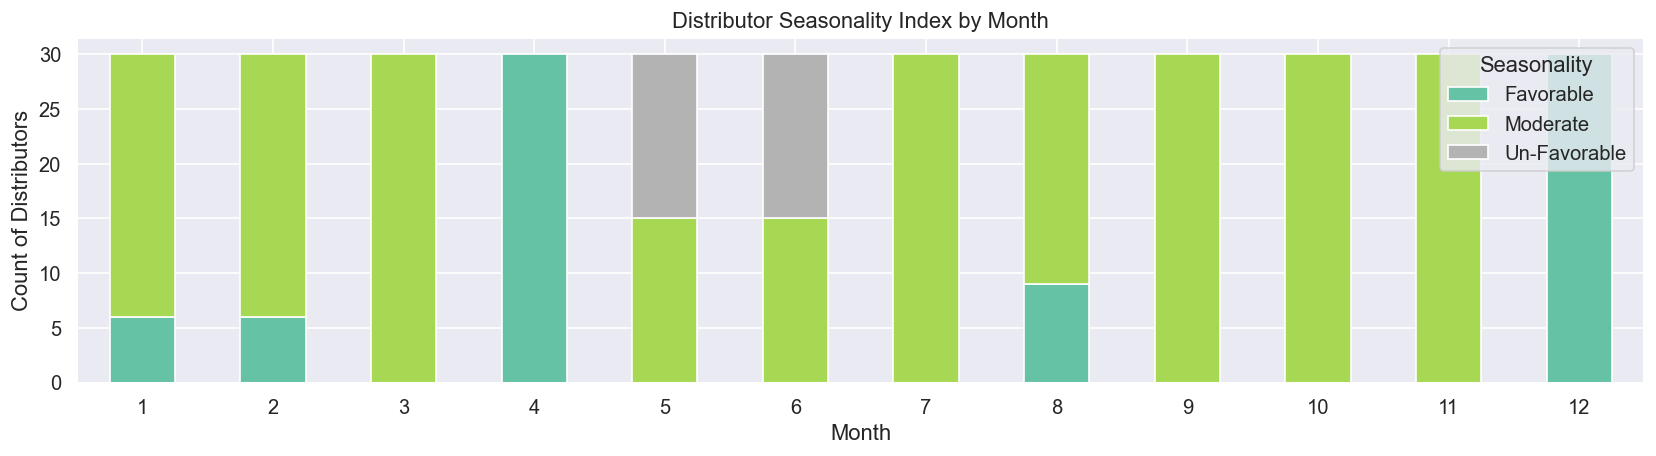

In [25]:
season_counts = season.groupby(['Month', 'Seasonality_Index']).size().unstack(fill_value=0)
season_counts.plot(kind='bar', stacked=True, figsize=(14, 4), colormap='Set2', edgecolor='white')
plt.title('Distributor Seasonality Index by Month')
plt.xlabel('Month')
plt.ylabel('Count of Distributors')
plt.xticks(rotation=0)
plt.legend(title='Seasonality')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_seasonality.png', bbox_inches='tight')
plt.show()

## 7. Gold Layer Feature Correlations

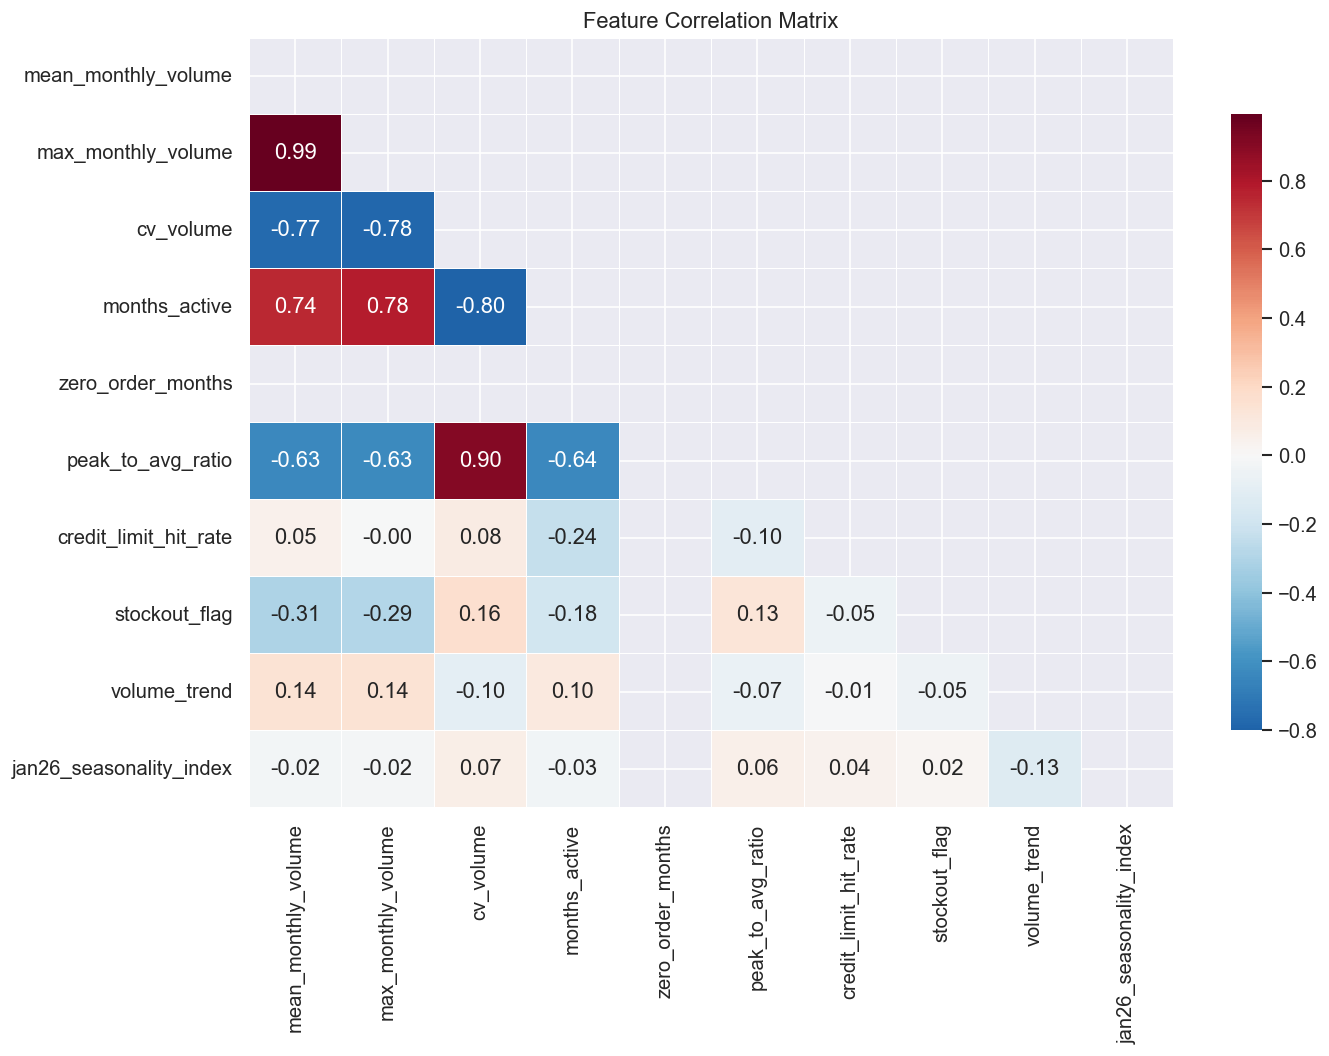

In [26]:
numeric_cols = gold.select_dtypes(include=[np.number]).columns.tolist()
core_cols = [
    'mean_monthly_volume', 'max_monthly_volume', 'cv_volume',
    'months_active', 'zero_order_months', 'peak_to_avg_ratio',
    'credit_limit_hit_rate', 'stockout_flag', 'volume_trend',
    'jan26_seasonality_index',
]
core_cols = [c for c in core_cols if c in gold.columns]

corr = gold[core_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_correlation_matrix.png', bbox_inches='tight')
plt.show()

## 8. Geographic Distribution (outlet map)

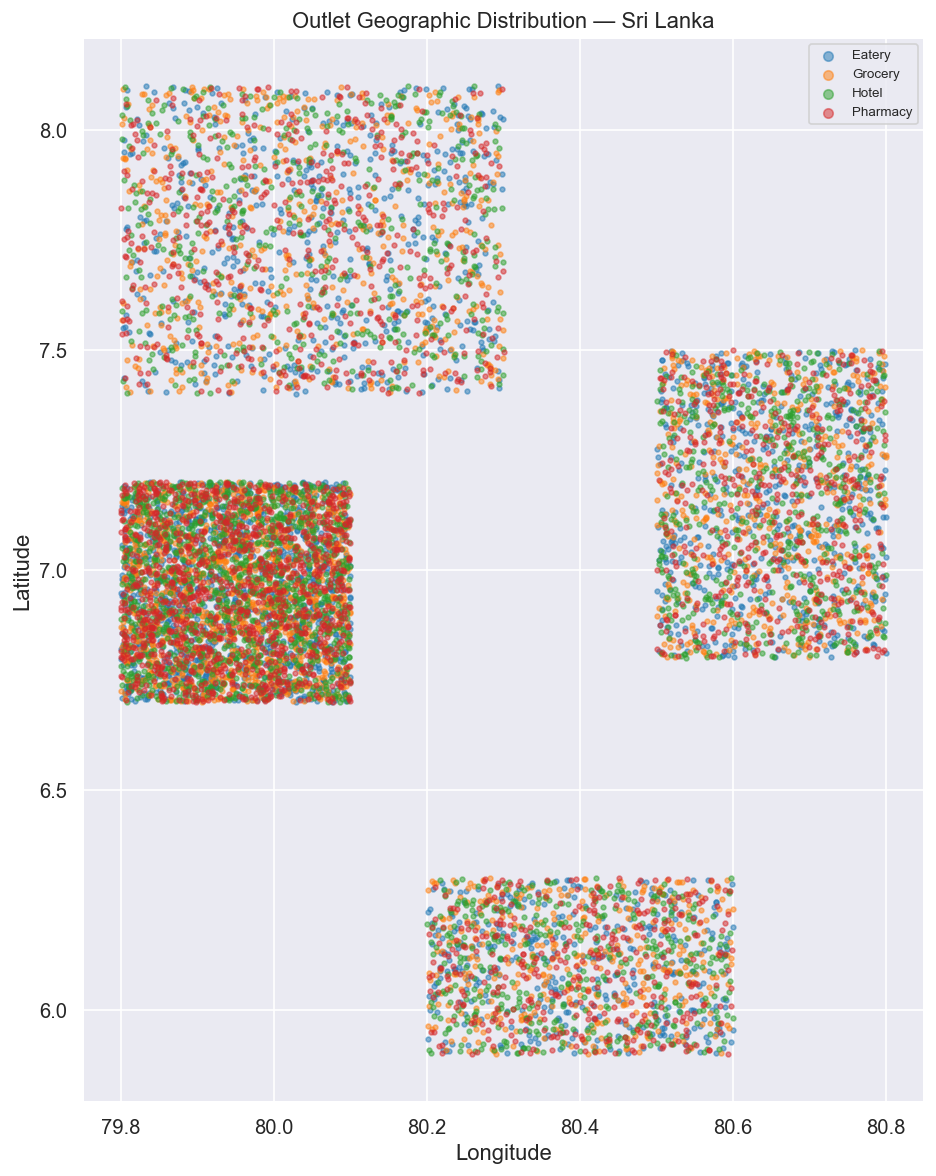

EDA complete. Charts saved to reports/


In [27]:
coords_master = coords.merge(master[['Outlet_ID', 'Outlet_Type']], on='Outlet_ID', how='left')

fig, ax = plt.subplots(figsize=(8, 10))
palette = sns.color_palette('tab10', n_colors=coords_master['Outlet_Type'].nunique())
for i, (otype, grp) in enumerate(coords_master.groupby('Outlet_Type')):
    ax.scatter(grp['Longitude'], grp['Latitude'], s=8, alpha=0.5,
               label=otype, color=palette[i])
ax.set_title('Outlet Geographic Distribution — Sri Lanka')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'eda_outlet_map.png', bbox_inches='tight')
plt.show()
print('EDA complete. Charts saved to reports/')